In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [26]:
df = pd.read_csv('../data/sg-tech-jobs-preprocessed-keywords_v2.csv')
df

,python,llm,data,production,ai,sql,cloud,senior,java,javascript,...,consulting,bank_finance,contract,renewable,hybrid,location,classifications/0/sub,workTypes/0,salary_lower,salary_upper
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,East,Help Desk & IT Support,Full time,3000.0,3500.0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,Central,Engineering - Network,Full time,6000.0,9000.0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,East,Help Desk & IT Support,Full time,2800.0,3500.0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,North,Help Desk & IT Support,Full time,4200.0,5200.0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,Central,Networks & Systems Administration,Full time,4000.0,5000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3393,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,Central,Engineering - Software,Full time,8000.0,12000.0
3394,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,Central,Developers/Programmers,Full time,4000.0,6000.0
3395,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,East,Sales - Pre & Post,Full time,4000.0,6000.0
3396,0,0,1,0,0,1,0,0,0,0,...,0,0,1,0,0,Central,Database Development & Administration,Contract/Temp,6000.0,NaN


In [27]:
numeric_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['salary_lower', 'salary_upper']]
numeric_features

['python',
 'llm',
 'data',
 'production',
 'ai',
 'sql',
 'cloud',
 'senior',
 'java',
 'javascript',
 'security',
 'git',
 'software_engineer',
 'communication',
 'proficient',
 'competitive',
 'healthcare',
 'consulting',
 'bank_finance',
 'contract',
 'renewable',
 'hybrid']

In [28]:
categorical_features = ['location', 'classifications/0/sub', 'workTypes/0']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# Salary Lower Bound

In [29]:
X_low = df.drop(['salary_lower', 'salary_upper'], axis=1)
y_low = df['salary_lower']

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low, y_low, test_size=0.2, random_state=42)

In [30]:
X_train_low

,python,llm,data,production,ai,sql,cloud,senior,java,javascript,...,competitive,healthcare,consulting,bank_finance,contract,renewable,hybrid,location,classifications/0/sub,workTypes/0
2155,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,Central,Programme & Project Management,Contract/Temp
2959,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,Central,Programme & Project Management,Full time
3237,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,Central,Management,Full time
3121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,North,Developers/Programmers,Full time
1746,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,Central,Developers/Programmers,Full time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,Unknown,Security,Full time
1130,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,Central,Engineering - Software,Full time
1294,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,Central,Management,Full time
860,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,East,Engineering - Software,Full time


In [31]:
y_train_low

2155     4000.0
2959     5000.0
3237      800.0
3121     4700.0
1746    10000.0
         ...   
1095     5500.0
1130     8000.0
1294     9000.0
860      6000.0
3174     5500.0
Name: salary_lower, Length: 2718, dtype: float64

In [32]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42))
])

cb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_state=42, verbose=0))
])

In [33]:
lr.fit(X_train_low, y_train_low)
y_pred_low_lr = lr.predict(X_test_low)
rmse_lr = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lr))
mae_lr = mean_absolute_error(y_test_low, y_pred_low_lr)
r2_lr = r2_score(y_test_low, y_pred_low_lr)

rf.fit(X_train_low, y_train_low)
y_pred_low_rf = rf.predict(X_test_low)
rmse_rf = np.sqrt(mean_squared_error(y_test_low, y_pred_low_rf))
mae_rf = mean_absolute_error(y_test_low, y_pred_low_rf)
r2_rf = r2_score(y_test_low, y_pred_low_rf)

xgb.fit(X_train_low, y_train_low)
y_pred_low_xgb = xgb.predict(X_test_low)
rmse_xgb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_xgb))
mae_xgb = mean_absolute_error(y_test_low, y_pred_low_xgb)
r2_xgb = r2_score(y_test_low, y_pred_low_xgb)

lgbm.fit(X_train_low, y_train_low)
y_pred_low_lgbm = lgbm.predict(X_test_low)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lgbm))
mae_lgbm = mean_absolute_error(y_test_low, y_pred_low_lgbm)
r2_lgbm = r2_score(y_test_low, y_pred_low_lgbm)

cb.fit(X_train_low, y_train_low)
y_pred_low_cb = cb.predict(X_test_low)
rmse_cb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_cb))
mae_cb = mean_absolute_error(y_test_low, y_pred_low_cb)
r2_cb = r2_score(y_test_low, y_pred_low_cb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 2718, number of used features: 41
[LightGBM] [Info] Start training from score 4813.429360


c:\Users\Dody Harianto\Documents\Personal Projects\ML Projects\SG Tech Jobs Salary Predictor\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb, rmse_lgbm, rmse_cb],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_lgbm, mae_cb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_cb]
}).sort_values(by='MAE')

results

,Model,RMSE,MAE,R2 Score
1,Random Forest,3802.327427,1298.960480,0.196384
2,XGBoost,3775.685059,1329.855321,0.207606
4,CatBoost,3780.209997,1404.646560,0.205705
3,LightGBM,3885.552798,1583.619905,0.160819
0,Linear Regression,3981.835379,1673.002566,0.118715


C:\Users\Dody Harianto\AppData\Local\Temp\ipykernel_13776\1388247514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results, palette='Set2')


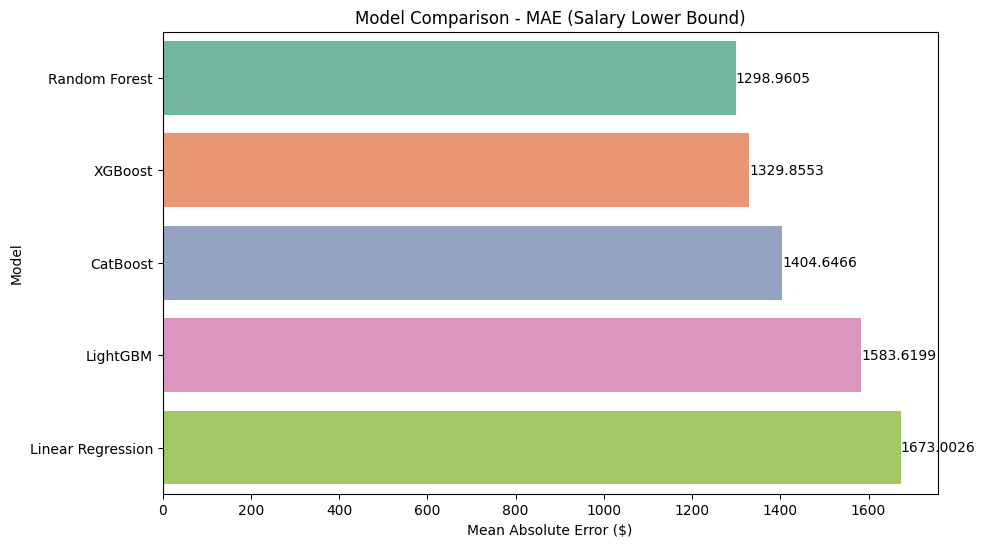

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE', y='Model', data=results, palette='Set2')
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.4f}', va='center')
plt.title('Model Comparison - MAE (Salary Lower Bound)')
plt.xlabel('Mean Absolute Error ($)')
plt.show()

In [36]:
joblib.dump(rf, '../models/rf_baseline_v2.pkl')

['../models/rf_baseline_v2.pkl']

# TF-IDF (With Work Types and Location)

In [ ]:
df = pd.read_csv('../data/sg-tech-jobs-preprocessed-corpus_worktypes_location.csv')
df

,location,classifications/0/sub,workTypes/0,text_corpus,salary_lower,salary_upper
0,East,Help Desk & IT Support,Full time,it support executive persol,3000.0,3500.0
1,Central,Engineering - Network,Full time,network engineer / senior network engineer sma...,6000.0,9000.0
2,East,Help Desk & IT Support,Full time,assistant it engineer (l1 support // semicondu...,2800.0,3500.0
3,North,Help Desk & IT Support,Full time,it analyst (end user services) seagate interna...,4200.0,5200.0
4,Central,Networks & Systems Administration,Full time,technical solution engineer caton technology a...,4000.0,5000.0
...,...,...,...,...,...,...
3393,Central,Engineering - Software,Full time,dh solution consulting engineer (ft handler) p...,8000.0,12000.0
3394,Central,Developers/Programmers,Full time,rpa developer certis group,4000.0,6000.0
3395,East,Sales - Pre & Post,Full time,sales engineer (gpu solutions & hardware) apba...,4000.0,6000.0
3396,Central,Database Development & Administration,Contract/Temp,"data engineer *sql - up $6000, ubi recruitfirs...",6000.0,NaN


In [38]:
categorical_features = ['location', 'classifications/0/sub', 'workTypes/0']

tf_idf = TfidfVectorizer(max_features=500, stop_words='english')

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tf_idf, 'text_corpus'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [39]:
X_low = df.drop(['salary_lower', 'salary_upper'], axis=1)
y_low = df['salary_lower']

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low, y_low, test_size=0.2, random_state=42)
X_train_low

,location,classifications/0/sub,workTypes/0,text_corpus
2155,Central,Programme & Project Management,Contract/Temp,"project manager (insurance, project management..."
2959,Central,Programme & Project Management,Full time,ict solutions specialist (digital health syste...
3237,Central,Management,Full time,senior resource planning & development manager...
3121,North,Developers/Programmers,Full time,embedded software engineer / software engineer...
1746,Central,Developers/Programmers,Full time,tts direction algorithm engineer x star techno...
...,...,...,...,...
1095,Unknown,Security,Full time,"assistant manager, information security & comp..."
1130,Central,Engineering - Software,Full time,dh solution consulting engineer (ft handler) p...
1294,Central,Management,Full time,"head, corporate transformation & services (npo..."
860,East,Engineering - Software,Full time,senior backend engineer reolink technology pte...


In [40]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42))
])

cb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_state=42, verbose=0))
])

In [41]:
lr.fit(X_train_low, y_train_low)
y_pred_low_lr = lr.predict(X_test_low)
rmse_lr = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lr))
mae_lr = mean_absolute_error(y_test_low, y_pred_low_lr)
r2_lr = r2_score(y_test_low, y_pred_low_lr)

rf.fit(X_train_low, y_train_low)
y_pred_low_rf = rf.predict(X_test_low)
rmse_rf = np.sqrt(mean_squared_error(y_test_low, y_pred_low_rf))
mae_rf = mean_absolute_error(y_test_low, y_pred_low_rf)
r2_rf = r2_score(y_test_low, y_pred_low_rf)

xgb.fit(X_train_low, y_train_low)
y_pred_low_xgb = xgb.predict(X_test_low)
rmse_xgb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_xgb))
mae_xgb = mean_absolute_error(y_test_low, y_pred_low_xgb)
r2_xgb = r2_score(y_test_low, y_pred_low_xgb)

lgbm.fit(X_train_low, y_train_low)
y_pred_low_lgbm = lgbm.predict(X_test_low)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lgbm))
mae_lgbm = mean_absolute_error(y_test_low, y_pred_low_lgbm)
r2_lgbm = r2_score(y_test_low, y_pred_low_lgbm)

cb.fit(X_train_low, y_train_low)
y_pred_low_cb = cb.predict(X_test_low)
rmse_cb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_cb))
mae_cb = mean_absolute_error(y_test_low, y_pred_low_cb)
r2_cb = r2_score(y_test_low, y_pred_low_cb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5278
[LightGBM] [Info] Number of data points in the train set: 2718, number of used features: 282
[LightGBM] [Info] Start training from score 4813.429360


c:\Users\Dody Harianto\Documents\Personal Projects\ML Projects\SG Tech Jobs Salary Predictor\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [42]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb, rmse_lgbm, rmse_cb],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_lgbm, mae_cb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_cb]
}).sort_values(by='MAE')

results

,Model,RMSE,MAE,R2 Score
1,Random Forest,881.694821,360.906278,0.956790
2,XGBoost,841.683628,536.785726,0.960623
4,CatBoost,968.926577,710.618236,0.947817
3,LightGBM,2220.372772,970.924034,0.725968
0,Linear Regression,3171.208234,1923.549835,0.441016


C:\Users\Dody Harianto\AppData\Local\Temp\ipykernel_13776\1388247514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results, palette='Set2')


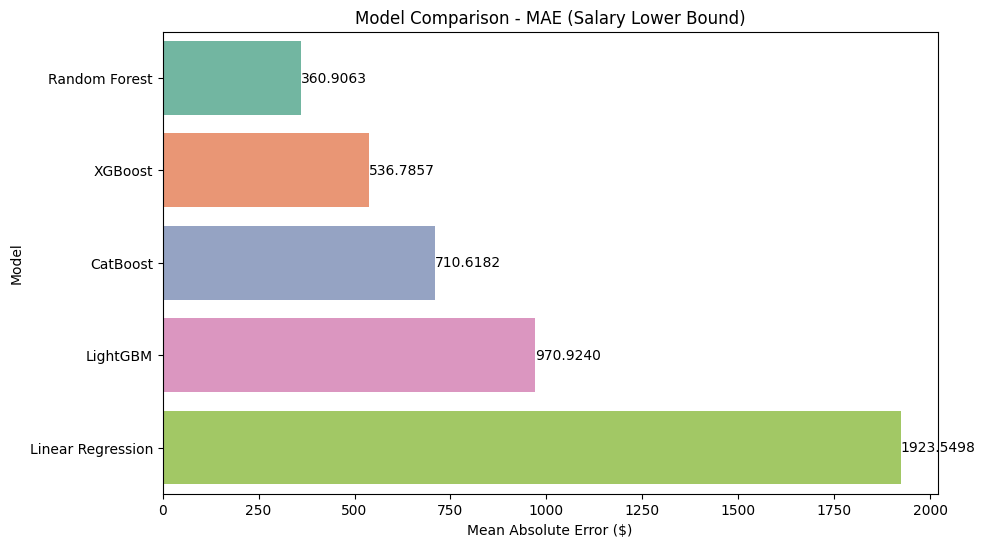

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE', y='Model', data=results, palette='Set2')
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.4f}', va='center')
plt.title('Model Comparison - MAE (Salary Lower Bound)')
plt.xlabel('Mean Absolute Error ($)')
plt.show()

In [44]:
model_path = '../models/rf_tf_idf.pkl'
joblib.dump(rf, model_path)

['../models/rf_tf_idf.pkl']

In [50]:
rf_tf_idf_pipeline = joblib.load(model_path)
rf_tf_idf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
rf_tf_idf_pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('text',
                                  TfidfVectorizer(max_features=500,
                                                  stop_words='english'),
                                  'text_corpus'),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['location', 'classifications/0/sub',
                                   'workTypes/0'])]),
 'model': RandomForestRegressor(random_state=42)}

In [59]:
learned_preprocessor = rf_tf_idf_pipeline.named_steps['preprocessor']
learned_rf_model = rf_tf_idf_pipeline.named_steps['model']

In [60]:
learned_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [52]:
learned_rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

The following are the 500 learned features for the pipeline consisting of TF-IDF and random forest.

In [65]:
learned_preprocessor.get_feature_names_out()

array(['text__000', 'text__0027', 'text__10', 'text__11', 'text__12',
       'text__14', 'text__18', 'text__2026', 'text__2209', 'text__2600',
       'text__3160', 'text__365', 'text__4000', 'text__4500', 'text__4k',
       'text__500', 'text__5000', 'text__5252', 'text__5500', 'text__5k',
       'text__6000', 'text__6500', 'text__6k', 'text__7000', 'text__7250',
       'text__7800', 'text__7k', 'text__800', 'text__8500', 'text__8k',
       'text__9398', 'text__9k', 'text__access', 'text__achieve',
       'text__adecco', 'text__admin', 'text__administrator',
       'text__advanced', 'text__advancement', 'text__advantage',
       'text__advertiser', 'text__advisory', 'text__agile', 'text__ai',
       'text__al', 'text__allied', 'text__allowance', 'text__alphaeus',
       'text__alpsoft', 'text__alwayshired', 'text__ambition',
       'text__analysis', 'text__analyst', 'text__analytics', 'text__ang',
       'text__angular', 'text__annual', 'text__apba', 'text__application',
       'text__

In [66]:
learned_rf_model.feature_importances_

array([6.54153513e-05, 1.01678550e-04, 1.36884217e-04, 1.56465321e-04,
       2.77471746e-04, 9.07869086e-07, 1.51445897e-05, 2.43392745e-05,
       1.19305341e-06, 4.46984365e-05, 4.41067823e-06, 1.08960249e-05,
       2.83320679e-05, 3.51719054e-05, 1.42375592e-04, 5.84577131e-06,
       3.31653639e-05, 1.79919763e-06, 7.49014505e-05, 1.06250435e-04,
       2.59804464e-05, 2.02333389e-05, 3.01004799e-05, 2.66217100e-05,
       8.63444135e-06, 1.30676630e-04, 5.83878196e-06, 2.64834080e-04,
       4.60167235e-05, 1.03118659e-04, 1.63585935e-05, 2.11624263e-04,
       1.19604018e-04, 3.79757130e-05, 3.57887716e-02, 7.47757402e-05,
       7.49291039e-04, 5.39764613e-05, 1.55233375e-05, 1.96950753e-04,
       5.35209653e-04, 1.11931802e-04, 3.49630993e-04, 2.95957532e-03,
       4.89766123e-07, 4.30087200e-05, 1.09630832e-05, 1.75887192e-03,
       4.19236831e-04, 5.34570679e-05, 3.18160859e-04, 2.71470547e-06,
       2.81408575e-03, 2.93363168e-05, 1.01428671e-04, 3.29221186e-04,
      

In [58]:
len(learned_rf_model.feature_importances_)

530

Top 20 most important features for predicting base salary.

In [72]:
feature_importance_df = pd.DataFrame({
    'Feature': learned_preprocessor.get_feature_names_out(),
    'Importance': learned_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_20_feature_importance = feature_importance_df.head(20)
top_20_feature_importance

,Feature,Importance
120,text__corporate,0.310385
267,text__leading,0.275977
514,cat__classifications/0/sub_Help Desk & IT Support,0.040683
34,text__adecco,0.035789
182,text__fast,0.035770
152,text__director,0.019680
285,text__manpower,0.018127
414,text__security,0.016879
284,text__manager,0.014033
59,text__architect,0.013103


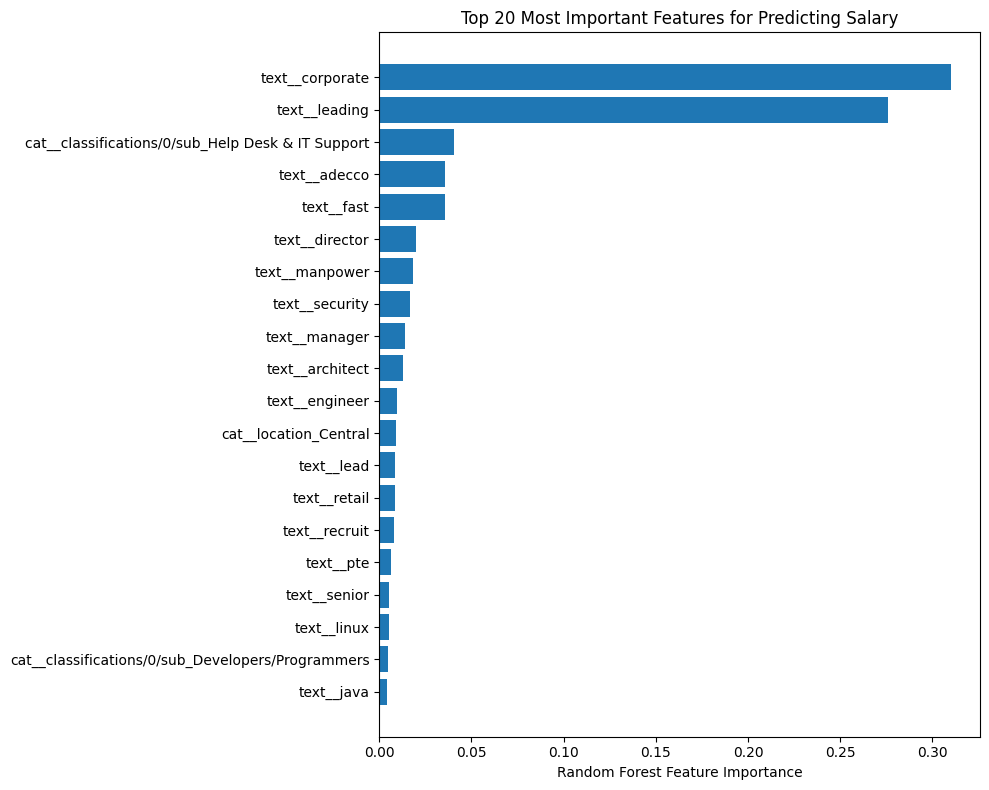

In [74]:
plt.figure(figsize=(10, 8))
plt.barh(top_20_feature_importance['Feature'][::-1], top_20_feature_importance['Importance'][::-1])
plt.title('Top 20 Most Important Features for Predicting Salary')
plt.xlabel('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# TF-IDF (Corpus Only)

In [3]:
df = pd.read_csv('../data/sg-tech-jobs-preprocessed-corpus-only.csv')
df

,text_corpus,salary_lower,salary_upper
0,it support executive persol,3000.0,3500.0
1,network engineer / senior network engineer sma...,6000.0,9000.0
2,assistant it engineer (l1 support // semicondu...,2800.0,3500.0
3,it analyst (end user services) seagate interna...,4200.0,5200.0
4,technical solution engineer caton technology a...,4000.0,5000.0
...,...,...,...
3393,dh solution consulting engineer (ft handler) p...,8000.0,12000.0
3394,rpa developer certis group,4000.0,6000.0
3395,sales engineer (gpu solutions & hardware) apba...,4000.0,6000.0
3396,"data engineer *sql - up $6000, ubi recruitfirs...",6000.0,NaN


In [4]:
tf_idf = TfidfVectorizer(max_features=500, stop_words='english')

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tf_idf, 'text_corpus')
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_n

In [5]:
X_low = df.drop(['salary_lower', 'salary_upper'], axis=1)
y_low = df['salary_lower']

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low, y_low, test_size=0.2, random_state=42)
X_train_low

,text_corpus
2155,"project manager (insurance, project management..."
2959,ict solutions specialist (digital health syste...
3237,senior resource planning & development manager...
3121,embedded software engineer / software engineer...
1746,tts direction algorithm engineer x star techno...
...,...
1095,"assistant manager, information security & comp..."
1130,dh solution consulting engineer (ft handler) p...
1294,"head, corporate transformation & services (npo..."
860,senior backend engineer reolink technology pte...


In [6]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42))
])

cb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_state=42, verbose=0))
])

In [7]:
lr.fit(X_train_low, y_train_low)
y_pred_low_lr = lr.predict(X_test_low)
rmse_lr = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lr))
mae_lr = mean_absolute_error(y_test_low, y_pred_low_lr)
r2_lr = r2_score(y_test_low, y_pred_low_lr)

rf.fit(X_train_low, y_train_low)
y_pred_low_rf = rf.predict(X_test_low)
rmse_rf = np.sqrt(mean_squared_error(y_test_low, y_pred_low_rf))
mae_rf = mean_absolute_error(y_test_low, y_pred_low_rf)
r2_rf = r2_score(y_test_low, y_pred_low_rf)

xgb.fit(X_train_low, y_train_low)
y_pred_low_xgb = xgb.predict(X_test_low)
rmse_xgb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_xgb))
mae_xgb = mean_absolute_error(y_test_low, y_pred_low_xgb)
r2_xgb = r2_score(y_test_low, y_pred_low_xgb)

lgbm.fit(X_train_low, y_train_low)
y_pred_low_lgbm = lgbm.predict(X_test_low)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_low, y_pred_low_lgbm))
mae_lgbm = mean_absolute_error(y_test_low, y_pred_low_lgbm)
r2_lgbm = r2_score(y_test_low, y_pred_low_lgbm)

cb.fit(X_train_low, y_train_low)
y_pred_low_cb = cb.predict(X_test_low)
rmse_cb = np.sqrt(mean_squared_error(y_test_low, y_pred_low_cb))
mae_cb = mean_absolute_error(y_test_low, y_pred_low_cb)
r2_cb = r2_score(y_test_low, y_pred_low_cb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5232
[LightGBM] [Info] Number of data points in the train set: 2718, number of used features: 259
[LightGBM] [Info] Start training from score 4813.429360


c:\Users\Dody Harianto\Documents\Personal Projects\ML Projects\SG Tech Jobs Salary Predictor\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [8]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb, rmse_lgbm, rmse_cb],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_lgbm, mae_cb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_cb]
}).sort_values(by='MAE')

results

,Model,RMSE,MAE,R2 Score
1,Random Forest,907.073079,370.592696,0.954267
2,XGBoost,806.738444,542.455707,0.963824
4,CatBoost,1003.631376,743.902960,0.944012
3,LightGBM,2298.630886,1040.266629,0.706311
0,Linear Regression,3214.864689,1952.051012,0.425520


C:\Users\Dody Harianto\AppData\Local\Temp\ipykernel_46276\1388247514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results, palette='Set2')


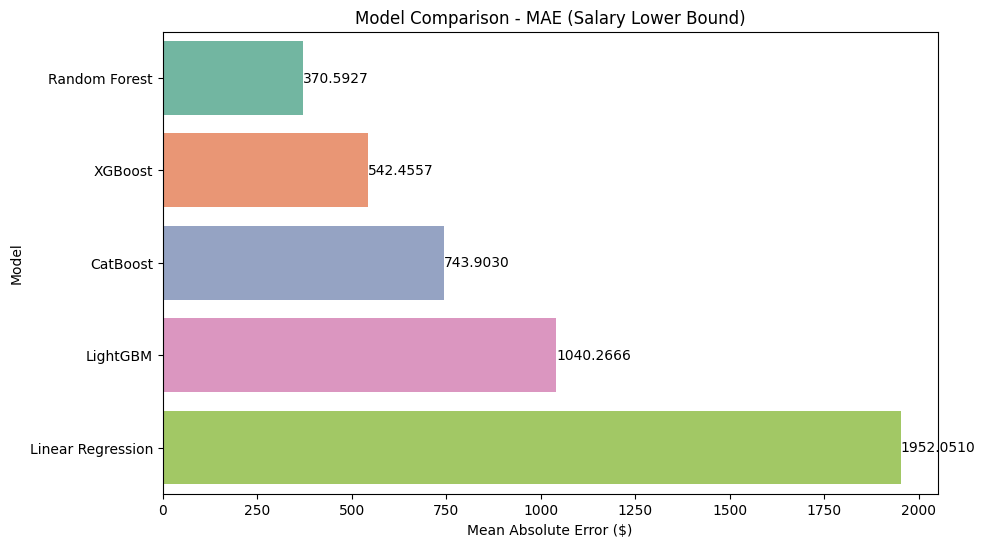

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE', y='Model', data=results, palette='Set2')
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.4f}', va='center')
plt.title('Model Comparison - MAE (Salary Lower Bound)')
plt.xlabel('Mean Absolute Error ($)')
plt.show()

In [10]:
model_path = '../models/rf_tf_idf_corpus_only.pkl'
joblib.dump(rf, model_path)

['../models/rf_tf_idf_corpus_only.pkl']